#**Mendeteksi Outlier Menggunakan K-Nearest Neighbors (KNN)**
#**1. Apa Itu Deteksi Outlier?**
Deteksi outlier adalah proses mengidentifikasi data yang berbeda secara signifikan dari sebagian besar data lainnya. Outlier dapat terjadi karena kesalahan pengukuran, kesalahan pencatatan data, atau memang merupakan informasi penting yang menyimpang dari pola umum.

#**2. Metode KNN dalam Deteksi Outlier**
Metode K-Nearest Neighbors (KNN) bekerja dengan cara:

- Menghitung jarak antara setiap titik dengan titik lainnya.
- Menentukan k tetangga terdekat untuk setiap titik.
- Menghitung rata-rata jarak ke k tetangga terdekat.
- Menentukan threshold untuk mendeteksi outlier berdasarkan distribusi jarak.
- Metode KNN dapat menggunakan berbagai metrik jarak, tetapi yang paling umum adalah Euclidean Distance.

#**3. Perhitungan Euclidean Distance dalam KNN**
Euclidean Distance antara dua titik 𝑝 dan 𝑞 dalam ruang 𝑛-dimensi dihitung dengan rumus:

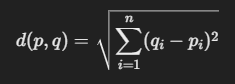

Jika kita memiliki dua titik dalam ruang dua dimensi, misalnya:

- 𝑝=(𝑥1,𝑦1)

- 𝑞=(𝑥2,𝑦2)

Maka jaraknya adalah:

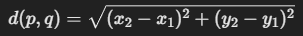


Contoh perhitungan sederhana:

Misalkan ada dua titik:

- 𝑝=(3,4)

- 𝑞=(6,8)
Maka:

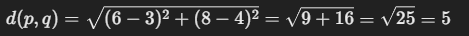

#**4. Rata-rata Jarak k Tetangga Terdekat**
Setelah menghitung jarak Euclidean antara titik-titik dalam dataset, kita dapat menentukan rata-rata jarak ke k tetangga terdekat.

Misalkan kita memiliki data:

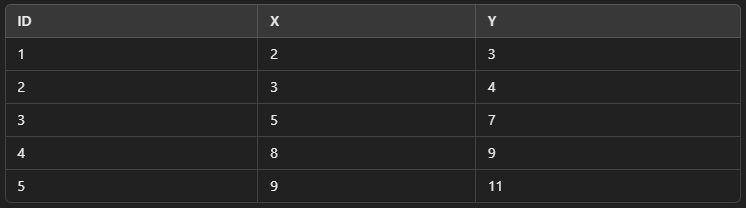

Jika kita memilih k = 3, maka untuk ID 1:

1. Hitung jarak ke setiap titik lainnya.
2. Pilih 3 tetangga terdekat.
3. Hitung rata-rata jarak ke 3 tetangga tersebut.

Rumus rata-rata jarak:

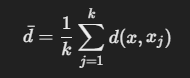

#**5. Langkah-Langkah Mendeteksi Outlier**

In [15]:
!pip install pymysql

In [16]:
!pip install psycopg2-binary

##**Mengambil Data PostgreSQL:**

In [17]:
import psycopg2

# Konfigurasi koneksi ke database Aiven PostgreSQL
host = "postgre23-112-postgresql23-112.h.aivencloud.com"
database = "defaultdb"
user = "avnadmin"
password = "AVNS_Ellqk9Jx9uICNV-C29t"
port = "15184"

try:
    # Koneksi ke database PostgreSQL
    conn = psycopg2.connect(host=host, database=database, user=user, password=password, port=port)
    cursor = conn.cursor()
    print("Koneksi PostgreSQL berhasil!")

    # Menjalankan query untuk mengambil data dari tabel `postgresql` dalam schema `postgresqliris`
    cursor.execute("SELECT * FROM postgresqliris.postgresql ORDER by id ASC;")
    rows = cursor.fetchall()

    # Menampilkan hasil query
    print("Data dalam tabel postgresqliris.postgresql:")
    for row in rows:
        print(row)

except psycopg2.OperationalError as e:
    # Menangani error jika koneksi gagal
    print(f"Error connecting to PostgreSQL: {e}")

finally:
    # Menutup koneksi database jika terbuka
    if 'conn' in locals() and not conn.closed:
        cursor.close()
        conn.close()
        print("Koneksi PostgreSQL ditutup.")


Koneksi PostgreSQL berhasil!
Data dalam tabel postgresqliris.postgresql:
(1, 'Iris-setosa', 20.1, 30.5)
(2, 'Iris-setosa', 4.9, 3.0)
(3, 'Iris-setosa', 4.7, 3.2)
(4, 'Iris-setosa', 4.6, 3.1)
(5, 'Iris-setosa', 5.0, 3.6)
(6, 'Iris-setosa', 5.4, 3.9)
(7, 'Iris-setosa', 4.6, 3.4)
(8, 'Iris-setosa', 5.0, 3.4)
(9, 'Iris-setosa', 4.4, 2.9)
(10, 'Iris-setosa', 4.9, 3.1)
(11, 'Iris-setosa', 5.4, 3.7)
(12, 'Iris-setosa', 4.8, 3.4)
(13, 'Iris-setosa', 4.8, 3.0)
(14, 'Iris-setosa', 4.3, 3.0)
(15, 'Iris-setosa', 5.8, 4.0)
(16, 'Iris-setosa', 5.7, 4.4)
(17, 'Iris-setosa', 5.4, 3.9)
(18, 'Iris-setosa', 5.1, 3.5)
(19, 'Iris-setosa', 5.7, 3.8)
(20, 'Iris-setosa', 5.1, 3.8)
(21, 'Iris-setosa', 5.4, 3.4)
(22, 'Iris-setosa', 5.1, 3.7)
(23, 'Iris-setosa', 4.6, 3.6)
(24, 'Iris-setosa', 5.1, 3.3)
(25, 'Iris-setosa', 4.8, 3.4)
(26, 'Iris-setosa', 5.0, 3.0)
(27, 'Iris-setosa', 5.0, 3.4)
(28, 'Iris-setosa', 5.2, 3.5)
(29, 'Iris-setosa', 5.2, 3.4)
(30, 'Iris-setosa', 4.7, 3.2)
(31, 'Iris-setosa', 4.8, 3.1)
(32,

##**Mengambil Data MySQL:**

In [18]:
import pymysql

# Konfigurasi koneksi ke database Aiven MySQL
host = "mysql23-112-irismysql23-112.h.aivencloud.com"
user = "avnadmin"
password = "AVNS_cTNd4CUt1kk0Z7MPIC1"
database = "defaultdb"
port = 15786

try:
    # Koneksi ke database MySQL
    conn = pymysql.connect(host=host, user=user, password=password, database=database, port=port)
    cursor = conn.cursor()
    print("Koneksi MySQL berhasil!")

    # Menjalankan query untuk mengambil data dari tabel `mysqliris` dalam schema `flowers`
    cursor.execute("SELECT * FROM mysqliris.flowers;")
    tables = cursor.fetchall()

    # Menampilkan hasil query
    print("Daftar tabel dalam defaultdb:")
    for table in tables:
        print(table)

except pymysql.err.OperationalError as e:
  # Menangani error jika koneksi gagal
    print(f"Error connecting to MySQL: {e}")

finally:
    # Menutup koneksi database jika terbuka
    if 'conn' in locals() and conn.open:
        cursor.close()
        conn.close()


Koneksi MySQL berhasil!
Daftar tabel dalam defaultdb:
(1, 'Iris-setosa', 86.4, 70.0)
(2, 'Iris-setosa', 1.4, 0.2)
(3, 'Iris-setosa', 1.3, 0.2)
(4, 'Iris-setosa', 1.5, 0.2)
(5, 'Iris-setosa', 1.4, 0.2)
(6, 'Iris-setosa', 1.7, 0.4)
(7, 'Iris-setosa', 1.4, 0.3)
(8, 'Iris-setosa', 1.5, 0.2)
(9, 'Iris-setosa', 1.4, 0.2)
(10, 'Iris-setosa', 1.5, 0.1)
(11, 'Iris-setosa', 1.5, 0.2)
(12, 'Iris-setosa', 1.6, 0.2)
(13, 'Iris-setosa', 1.4, 0.1)
(14, 'Iris-setosa', 1.1, 0.1)
(15, 'Iris-setosa', 1.2, 0.2)
(16, 'Iris-setosa', 1.5, 0.4)
(17, 'Iris-setosa', 1.3, 0.4)
(18, 'Iris-setosa', 1.4, 0.3)
(19, 'Iris-setosa', 1.7, 0.3)
(20, 'Iris-setosa', 1.5, 0.3)
(21, 'Iris-setosa', 1.7, 0.2)
(22, 'Iris-setosa', 1.5, 0.4)
(23, 'Iris-setosa', 1.0, 0.2)
(24, 'Iris-setosa', 1.7, 0.5)
(25, 'Iris-setosa', 1.9, 0.2)
(26, 'Iris-setosa', 1.6, 0.2)
(27, 'Iris-setosa', 1.6, 0.4)
(28, 'Iris-setosa', 1.5, 0.2)
(29, 'Iris-setosa', 1.4, 0.2)
(30, 'Iris-setosa', 1.6, 0.2)
(31, 'Iris-setosa', 1.6, 0.2)
(32, 'Iris-setosa', 1.5

##**Menggabungkan Database MySQL dan PostgreSQL**

In [19]:
import pymysql
import psycopg2
import pandas as pd

# Konfigurasi koneksi ke database Aiven MySQL
mysql_config = {
    "host": "mysql23-112-irismysql23-112.h.aivencloud.com",
    "user": "avnadmin",
    "password": "AVNS_cTNd4CUt1kk0Z7MPIC1",
    "database": "defaultdb",
    "port": 15786
}

# Konfigurasi koneksi ke database Aiven PostgreSQL
postgres_config = {
    "host": "postgre23-112-postgresql23-112.h.aivencloud.com",
    "database": "defaultdb",
    "user": "avnadmin",
    "password": "AVNS_Ellqk9Jx9uICNV-C29t",
    "port": 15184
}

# Fungsi untuk mengambil data dari MySQL (hanya petal length & petal width)
def fetch_mysql_data():
    try:
        conn = pymysql.connect(**mysql_config)
        cursor = conn.cursor()
        query = 'SELECT id, class, `petal length`, `petal width` FROM mysqliris.flowers;'
        cursor.execute(query)
        data = cursor.fetchall()
        columns = [desc[0] for desc in cursor.description]  # Ambil nama kolom
        cursor.close()
        conn.close()
        df = pd.DataFrame(data, columns=columns)

        # Ubah nama kolom agar seragam
        df = df.rename(columns={"petal length": "petal_length", "petal width": "petal_width"})

        return df
    except pymysql.err.OperationalError as e:
        print(f"Error connecting to MySQL: {e}")
        return pd.DataFrame()

# Fungsi untuk mengambil data dari PostgreSQL (hanya sepal length & sepal width)
def fetch_postgres_data():
    try:
        conn = psycopg2.connect(**postgres_config)
        cursor = conn.cursor()
        query = 'SELECT id, "Class", "sepal length", "sepal width" FROM postgresqliris.postgresql ORDER by id ASC;'
        cursor.execute(query)
        data = cursor.fetchall()
        columns = [desc[0] for desc in cursor.description]  # Ambil nama kolom
        cursor.close()
        conn.close()
        df = pd.DataFrame(data, columns=columns)

        # Ubah nama kolom agar seragam
        df = df.rename(columns={"Class": "class", "sepal length": "sepal_length", "sepal width": "sepal_width"})

        return df
    except psycopg2.OperationalError as e:
        print(f"Error connecting to PostgreSQL: {e}")
        return pd.DataFrame()

# Ambil data dari kedua database
mysql_df = fetch_mysql_data()
postgres_df = fetch_postgres_data()

# Gabungkan data berdasarkan id dan class
combined_df = pd.merge(postgres_df, mysql_df, on=["id", "class"], how="inner")

# Tampilkan hasil
print("\nData Gabungan dari MySQL dan PostgreSQL:")
print(combined_df.to_string(index=False))



Data Gabungan dari MySQL dan PostgreSQL:
 id           class  sepal_length  sepal_width  petal_length  petal_width
  1     Iris-setosa          20.1         30.5          86.4         70.0
  2     Iris-setosa           4.9          3.0           1.4          0.2
  3     Iris-setosa           4.7          3.2           1.3          0.2
  4     Iris-setosa           4.6          3.1           1.5          0.2
  5     Iris-setosa           5.0          3.6           1.4          0.2
  6     Iris-setosa           5.4          3.9           1.7          0.4
  7     Iris-setosa           4.6          3.4           1.4          0.3
  8     Iris-setosa           5.0          3.4           1.5          0.2
  9     Iris-setosa           4.4          2.9           1.4          0.2
 10     Iris-setosa           4.9          3.1           1.5          0.1
 11     Iris-setosa           5.4          3.7           1.5          0.2
 12     Iris-setosa           4.8          3.4           1.6          

##K**ode yang digunakan untuk mencari KNN dengan Perhitungan Euclidean Distance**

In [20]:
import numpy as np
import pandas as pd
from sklearn.neighbors import LocalOutlierFactor
from tabulate import tabulate

# Pastikan combined_df sudah berisi data
if not combined_df.empty:
    # Pilih fitur numerik yang akan digunakan untuk deteksi outlier
    features = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
    data = combined_df[features]

    # Tetapkan nilai k secara langsung
    k = 5

    # Inisialisasi model KNN untuk deteksi outlier
    lof = LocalOutlierFactor(n_neighbors=k, metric='minkowski')

    # Fit model dan dapatkan prediksi
    lof.fit(data)
    combined_df["distance"] = -lof.negative_outlier_factor_  # Konversi ke nilai positif

    # Tampilkan semua data dengan tabulate
    print("\nData dengan Distance:")
    print(tabulate(combined_df.drop(columns=["outlier"], errors='ignore'), headers='keys', tablefmt='psql'))
else:
    print("Data gabungan kosong. Pastikan koneksi ke database berhasil dan data tersedia.")



Data dengan Distance:
+-----+------+-----------------+----------------+---------------+----------------+---------------+------------+
|     |   id | class           |   sepal_length |   sepal_width |   petal_length |   petal_width |   distance |
|-----+------+-----------------+----------------+---------------+----------------+---------------+------------|
|   0 |    1 | Iris-setosa     |           20.1 |          30.5 |           86.4 |          70   | 133.749    |
|   1 |    2 | Iris-setosa     |            4.9 |           3   |            1.4 |           0.2 |   1.00322  |
|   2 |    3 | Iris-setosa     |            4.7 |           3.2 |            1.3 |           0.2 |   1.10073  |
|   3 |    4 | Iris-setosa     |            4.6 |           3.1 |            1.5 |           0.2 |   1.01717  |
|   4 |    5 | Iris-setosa     |            5   |           3.6 |            1.4 |           0.2 |   1.03361  |
|   5 |    6 | Iris-setosa     |            5.4 |           3.9 |            1.7 

##**Penjelasan Perhitungan Euclidean Distance pada KNN pada code**
###**Apa itu Euclidean Distance?**
Euclidean Distance adalah jarak lurus (garis terpendek) antara dua titik dalam ruang multidimensi.
Rumus Euclidean Distance antara dua titik A dan B dalam ruang n-dimensi adalah:

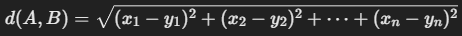

Di dalam kode, dataset memiliki 4 fitur (sepal_length, sepal_width, petal_length, petal_width), sehingga Euclidean Distance antara dua sampel dihitung sebagai:

image.png

###**Bagaimana Euclidean Distance Digunakan dalam KNN Outlier Detection?**

1.   Membentuk Data
*   Dataset memiliki beberapa sampel dengan fitur sepal_length, sepal_width, petal_length, petal_width.
*   Data ini digunakan untuk menghitung jarak antar titik.

2.   Menentukan Tetangga Terdekat (KNN)
* Model LocalOutlierFactor (LOF) digunakan dengan k=5, artinya setiap titik dibandingkan dengan 5 tetangga terdekat.
* Jarak dihitung menggunakan Euclidean Distance.

3.   Menghitung Skor Outlier
* Local Outlier Factor (LOF) menilai apakah suatu titik adalah outlier berdasarkan rata-rata jarak K tetangga terdekatnya.
* LOF akan memberikan negative outlier factor (-LOF.negative_outlier_factor_), yang dikonversi ke nilai positif sebagai "distance score" untuk mempermudah interpretasi.

In [21]:
import numpy as np
import pandas as pd
from tabulate import tabulate

# Pastikan combined_df sudah berisi data
if not combined_df.empty:
    # Tetapkan threshold berdasarkan quantile
    threshold = np.percentile(combined_df["distance"], 99.999)  # Misalnya 99th percentile
    outliers = combined_df[combined_df["distance"] > threshold]  # Data yang dianggap outlier

    # Tampilkan hanya data outlier dengan tabulate
    print("\nData Outlier:")
    print(tabulate(outliers, headers='keys', tablefmt='psql'))
else:
    print("Data gabungan kosong. Pastikan koneksi ke database berhasil dan data tersedia.")



Data Outlier:
+----+------+-------------+----------------+---------------+----------------+---------------+------------+
|    |   id | class       |   sepal_length |   sepal_width |   petal_length |   petal_width |   distance |
|----+------+-------------+----------------+---------------+----------------+---------------+------------|
|  0 |    1 | Iris-setosa |           20.1 |          30.5 |           86.4 |            70 |    133.749 |
+----+------+-------------+----------------+---------------+----------------+---------------+------------+


###**Penjelasan Kode**
`if not combined_df.empty:`
- combined_df.empty → Mengecek apakah combined_df kosong atau tidak.
- not combined_df.empty → Jika combined_df tidak kosong, maka lanjut ke proses berikutnya.
- Jika combined_df kosong, maka program akan mencetak pesan error.

`threshold = np.percentile(combined_df["distance"], 99.999)`
- np.percentile() → Menghitung persentil dari kolom distance dalam combined_df.
- Persentil 99.999 → Menentukan batas threshold untuk outlier.
- Semua data yang memiliki "distance" lebih besar dari threshold ini akan dianggap sebagai outlier.

📌 Penjelasan Threshold:

- Misalkan kita memiliki 1.000.000 data, maka hanya 1 data (0.001%) yang akan dianggap sebagai outlier dengan threshold 99.999th percentile.
- Semakin tinggi nilai persentil, semakin sedikit data yang dianggap outlier

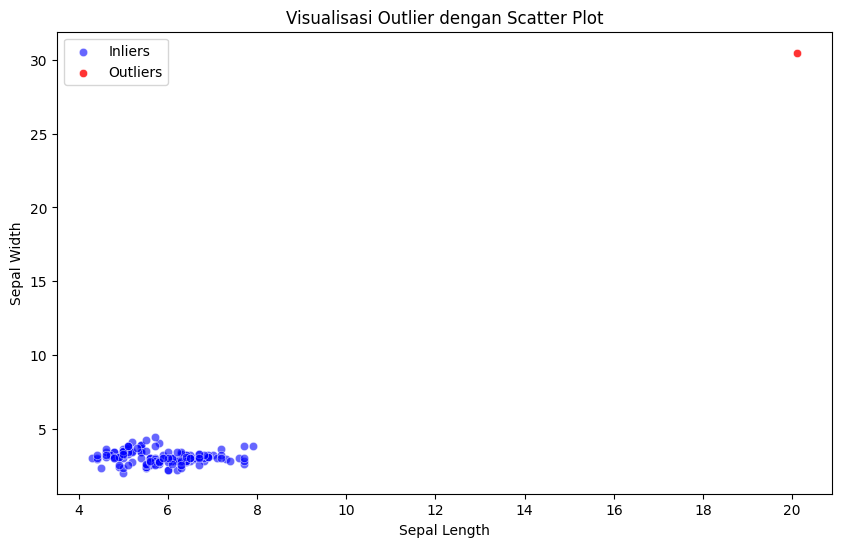

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Pastikan combined_df sudah berisi data
if not combined_df.empty:
    # Tetapkan threshold berdasarkan quantile
    threshold = np.percentile(combined_df["distance"], 99.999)

    # Pisahkan data inlier dan outlier
    outliers = combined_df[combined_df["distance"] > threshold]
    inliers = combined_df[combined_df["distance"] <= threshold]

    # Plot scatter plot
    plt.figure(figsize=(10, 6))

    # Plot inlier (data normal)
    sns.scatterplot(x=inliers["sepal_length"], y=inliers["sepal_width"], color='blue', label='Inliers', alpha=0.6)

    # Plot outlier (data yang dideteksi sebagai outlier)
    sns.scatterplot(x=outliers["sepal_length"], y=outliers["sepal_width"], color='red', label='Outliers', alpha=0.8,)

    # Tambahkan judul dan label
    plt.title("Visualisasi Outlier dengan Scatter Plot")
    plt.xlabel("Sepal Length")
    plt.ylabel("Sepal Width")
    plt.legend()
    plt.show()
else:
    print("Data gabungan kosong. Pastikan koneksi ke database berhasil dan data tersedia.")


### **Elemen-elemen dalam Scatter Plot**  

Scatter plot adalah grafik yang digunakan untuk menunjukkan hubungan antara dua variabel numerik. Berikut adalah elemen-elemen utama dalam scatter plot:

1. **Sumbu X (X-Axis)**  
   - Menampilkan variabel pertama yang digunakan sebagai **independen (predictor)**.  
   - Dalam kasus analisis outlier, bisa berupa **sepal_length** atau **petal_length**.

2. **Sumbu Y (Y-Axis)**  
   - Menampilkan variabel kedua yang digunakan sebagai **dependen (response)**.  
   - Misalnya, **sepal_width** atau **petal_width**.

3. **Titik Data (Data Points)**  
   - Setiap titik mewakili **satu observasi** dalam dataset.  
   - Posisi titik ditentukan oleh nilai pada **sumbu X dan Y**.

4. **Warna dan Bentuk Titik (Color & Marker Style)**  
   - Warna dapat digunakan untuk membedakan **inlier (data normal) dan outlier**.  
   - Biasanya:
     - **Biru** untuk data normal.
     - **Merah** untuk outlier.
   - Marker bisa berbentuk **lingkaran (o) untuk data normal** dan **X untuk outlier**.

5. **Judul Plot (Title)**  
   - Menjelaskan isi scatter plot, misalnya:  
     _"Visualisasi Outlier pada Sepal Length vs. Sepal Width"_

6. **Label Sumbu (Axis Labels)**  
   - Menunjukkan apa yang diwakili oleh **sumbu X** dan **sumbu Y**.  
   - Contoh:  
     - **X-Axis:** _"Sepal Length (cm)"_  
     - **Y-Axis:** _"Sepal Width (cm)"_

7. **Legenda (Legend)**  
   - Menjelaskan arti warna atau bentuk titik data.  
   - Contoh:  
     - **Biru:** Data Normal  
     - **Merah:** Outlier  

8. **Grid (Opsional)**  
   - Garis bantu untuk memudahkan membaca nilai titik data.  
   - Bisa diaktifkan menggunakan `plt.grid(True)`.  

### **Kesimpulan**  
Scatter plot membantu **menganalisis pola dan distribusi data**, serta **mengidentifikasi outlier** dengan visual yang jelas. 🚀

#**Kelebihan & Kekurangan KNN**
✅ Kelebihan:

- Mudah diimplementasikan & tidak membutuhkan pelatihan model kompleks.
- Bisa digunakan untuk klasifikasi, regresi, dan deteksi outlier.
- Akurasi tinggi untuk dataset kecil hingga menengah.


❌ Kekurangan:

- Lambat untuk dataset besar (harus menghitung jarak ke semua titik).
- Sensitif terhadap skala fitur (perlu normalisasi).
- Pemilihan 𝑘 sangat krusial untuk hasil yang baik.